# 4장 실습 — 무엇이 실제로 빨라지는가

2부는 모델을 작게 만든다. 첫 장은 **무엇이 실제로 빨라지는지**를 재는 것으로 시작한다.

「양자화하면 4배 빨라진다」는 문장은 대개 두 가지를 감춘다. 첫째, 빨라지는 것은 모델의 일부이지 전부가 아니다. 둘째, 그 배수는 **하드웨어와 연산자 구성**에 달려 있어서 다른 자리로 옮겨지지 않는다.

이 노트북은 2장과 같은 세 가지 크기의 모델에 실제 INT8 양자화를 걸고, 3장의 규약대로 잰다. 트랜스포머는 `nn.TransformerEncoderLayer` 대신 **`Linear` 로 풀어 썼다** — 무엇이 양자화되고 무엇이 안 되는지 보이게 하려는 것이다.

실행 시간은 CPU에서 3분 안팎이다.

In [1]:
%pip install -q koreanize-matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import io
import time
import warnings
import unicodedata
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import koreanize_matplotlib  # noqa: F401


def dw(s):
    return sum(2 if unicodedata.east_asian_width(c) in "WF" else 1
               for c in str(s))


def pad(s, n, right=False):
    gap = " " * max(n - dw(s), 0)
    return gap + str(s) if right else str(s) + gap


RED, GREY, INK = "#E32C24", "#8C8A85", "#1C1C1A"
PINK = "#F3A29D"
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True,
                     "grid.alpha": .25, "axes.spines.top": False,
                     "axes.spines.right": False})
warnings.filterwarnings("ignore")
torch.set_num_threads(2)
torch.manual_seed(0)
print("torch", torch.__version__)

torch 2.14.0+cu130


## 표기법을 먼저 정한다

문헌에서 양자화 설정을 **W4A8** 같은 꼴로 적는다. W 뒤의 수가 가중치 비트, A 뒤의 수가 활성값 비트다.

- **W8A32 / W4A16** — 가중치만 줄인다. 메모리와 대역폭은 줄지만 연산은 여전히 부동소수점이다
- **W8A8 / W4A8** — 활성값까지 줄인다. 정수 연산 커널을 쓸 수 있어 계산 자체가 빨라진다
- **W4A4** — 가장 공격적이다. 6장에서 이 설정의 논문들을 본다

구분이 중요한 이유는 **이득의 출처가 다르기 때문**이다. 가중치만 줄이면 모델이 메모리에 덜 앉고 읽어 오는 시간이 준다. 활성값까지 줄여야 곱셈이 싸진다. 그리고 큰 모델의 추론은 대개 메모리 대역폭에 묶여 있어서, 가중치만 줄여도 꽤 빨라진다.

PyTorch의 동적 양자화는 **가중치를 INT8로 저장하고 활성값을 실행 시점에 INT8로 양자화**한다. 대략 W8A8이고, 적용 대상은 `Linear` 계열이다.

In [3]:
S = 224


class StateMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.f = nn.Sequential(nn.Linear(8, 64), nn.Tanh(),
                               nn.Linear(64, 64), nn.Tanh(),
                               nn.Linear(64, 2))

    def forward(self, x):
        return self.f(x)


class SmallCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.f = nn.Sequential(
            nn.Conv2d(3, 16, 5, 4, 2), nn.ReLU(),
            nn.Conv2d(16, 32, 3, 2, 1), nn.ReLU(),
            nn.Conv2d(32, 64, 3, 2, 1), nn.ReLU(),
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Linear(64, 64), nn.ReLU(), nn.Linear(64, 2))

    def forward(self, x):
        return self.f(x)


class Block(nn.Module):
    """트랜스포머 블록을 Linear 로 풀어 쓴다 — 무엇이
    양자화되는지 보이게 하려는 것이다."""

    def __init__(self, dim, heads):
        super().__init__()
        self.h = heads
        self.n1 = nn.LayerNorm(dim)
        self.n2 = nn.LayerNorm(dim)
        self.qkv = nn.Linear(dim, dim * 3)
        self.proj = nn.Linear(dim, dim)
        self.fc1 = nn.Linear(dim, dim * 4)
        self.fc2 = nn.Linear(dim * 4, dim)

    def forward(self, x):
        B, N, D = x.shape
        q, k, v = self.qkv(self.n1(x)).chunk(3, -1)
        sh = (B, N, self.h, D // self.h)
        q = q.view(sh).transpose(1, 2)
        k = k.view(sh).transpose(1, 2)
        v = v.view(sh).transpose(1, 2)
        a = torch.nn.functional.scaled_dot_product_attention(q, k, v)
        x = x + self.proj(a.transpose(1, 2).reshape(B, N, D))
        z = torch.nn.functional.gelu(self.fc1(self.n2(x)))
        return x + self.fc2(z)


class TinyViT(nn.Module):
    def __init__(self, dim=384, depth=6, heads=6):
        super().__init__()
        self.patch = nn.Conv2d(3, dim, 16, 16)
        self.pos = nn.Parameter(torch.zeros(1, (S // 16) ** 2, dim))
        self.blocks = nn.ModuleList(
            [Block(dim, heads) for _ in range(depth)])
        self.norm = nn.LayerNorm(dim)
        self.head = nn.Linear(dim, 2)

    def forward(self, x):
        z = self.patch(x).flatten(2).transpose(1, 2) + self.pos
        for b in self.blocks:
            z = b(z)
        return self.head(self.norm(z).mean(1))


CASES = {
    "상태 MLP": (StateMLP().eval(), torch.randn(1, 8)),
    "작은 CNN": (SmallCNN().eval(), torch.randn(1, 3, S, S)),
    "트랜스포머": (TinyViT().eval(), torch.randn(1, 3, S, S)),
}


def blob(m):
    b = io.BytesIO()
    torch.save(m.state_dict(), b)
    return b.getbuffer().nbytes / 1e6


def linear_share(m):
    """Linear 계층이 파라미터에서 차지하는 비율"""
    tot = sum(p.numel() for p in m.parameters())
    lin = sum(p.numel() for mod in m.modules()
              if isinstance(mod, nn.Linear)
              for p in mod.parameters())
    return lin / tot


print(pad("모델", 14) + pad("파라미터", 14, True)
      + pad("크기 MB", 11, True) + pad("Linear 비중", 14, True))
for name, (m, _) in CASES.items():
    n = sum(p.numel() for p in m.parameters())
    print(pad(name, 14) + pad(f"{n:,}", 14, True)
          + pad(f"{blob(m):.2f}", 11, True)
          + pad(f"{linear_share(m) * 100:.0f}%", 14, True))

모델                파라미터    크기 MB   Linear 비중
상태 MLP               4,866       0.02          100%
작은 CNN              28,642       0.12           15%
트랜스포머        11,018,882      44.10           97%


In [4]:
from torch.ao.quantization import quantize_dynamic


def timeit(m, x, reps=140, warm=20):
    ts = []
    for i in range(reps + warm):
        t0 = time.perf_counter_ns()
        with torch.no_grad():
            m(x)
        if i >= warm:
            ts.append((time.perf_counter_ns() - t0) / 1e6)
    return np.array(ts)


t0 = time.time()
RES = {}
for name, (m, x) in CASES.items():
    q = quantize_dynamic(m, {nn.Linear}, dtype=torch.qint8)
    RES[name] = dict(fp=timeit(m, x), q=timeit(q, x),
                     sz_fp=blob(m), sz_q=blob(q), qm=q)
    print(f"{name} 끝  ({time.time() - t0:.0f}s)")

상태 MLP 끝  (0s)


작은 CNN 끝  (0s)


트랜스포머 끝  (12s)


In [5]:
print(pad("모델", 14) + pad("FP32 p50", 11, True)
      + pad("INT8 p50", 11, True) + pad("배수", 8, True)
      + pad("크기 배수", 12, True))
for name, r in RES.items():
    a = np.percentile(r["fp"], 50)
    b = np.percentile(r["q"], 50)
    print(pad(name, 14) + pad(f"{a:.2f}", 11, True)
          + pad(f"{b:.2f}", 11, True)
          + pad(f"{a / b:.2f}배", 8, True)
          + pad(f"{r['sz_fp'] / r['sz_q']:.2f}배", 12, True))
print()
print("p50 단위는 ms  ·  140판  ·  워밍업 20판 제외")

모델             FP32 p50   INT8 p50    배수   크기 배수
상태 MLP             0.05       0.14  0.39배      2.22배
작은 CNN             0.80       0.93  0.86배      1.10배
트랜스포머          41.72      25.04  1.67배      3.60배

p50 단위는 ms  ·  140판  ·  워밍업 20판 제외


## 배수는 하나의 수가 아니다

세 모델의 배수가 다르다. 그리고 그 차이가 **Linear 비중**과 거의 그대로 대응한다.

작은 CNN은 파라미터의 대부분이 합성곱에 있어서 동적 양자화가 손댈 것이 거의 없다. 상태 MLP는 전부 Linear 인데도 **오히려 느려진다** — 모델이 너무 작아 양자화·역양자화 비용이 계산 비용보다 크기 때문이다. 이 줄이 특히 중요하다. 「양자화는 최소한 손해는 아니다」가 참이 아니다.

트랜스포머는 파라미터가 거의 전부 Linear 이고 행렬도 충분히 커서 이득이 나온다.

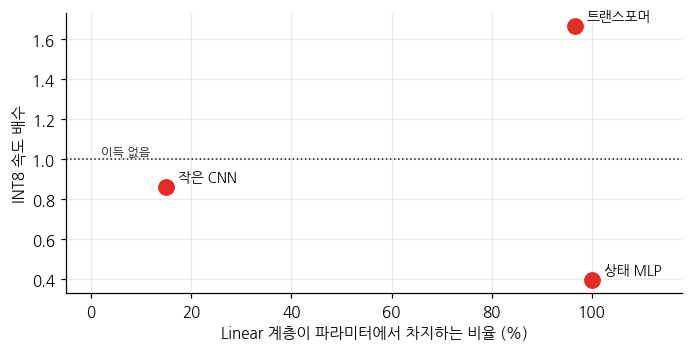

In [6]:
fig, ax = plt.subplots(figsize=(6.4, 3.3))
names = list(RES)
sh = [linear_share(CASES[n][0]) * 100 for n in names]
sp = [np.percentile(RES[n]["fp"], 50)
      / np.percentile(RES[n]["q"], 50) for n in names]
ax.plot(sh, sp, "o", color=RED, ms=10)
for x, y, n in zip(sh, sp, names):
    ax.annotate(n, (x, y), fontsize=9, xytext=(8, 4),
                textcoords="offset points")
ax.axhline(1., color=INK, lw=1, ls=":")
ax.text(2, 1.02, "이득 없음", fontsize=8, color=INK)
ax.set_xlim(-5, 118)
ax.set_xlabel("Linear 계층이 파라미터에서 차지하는 비율 (%)")
ax.set_ylabel("INT8 속도 배수")
plt.tight_layout()
plt.show()

In [7]:
print(pad("모델", 14) + pad("정밀도", 9) + pad("p50", 9, True)
      + pad("p99", 9, True) + pad("p99/p50", 11, True))
for name, r in RES.items():
    for lab, key in (("FP32", "fp"), ("INT8", "q")):
        v = r[key]
        p50 = np.percentile(v, 50)
        p99 = np.percentile(v, 99)
        print(pad(name, 14) + pad(lab, 9)
              + pad(f"{p50:.2f}", 9, True)
              + pad(f"{p99:.2f}", 9, True)
              + pad(f"{p99 / p50:.1f}배", 11, True))

모델          정밀도         p50      p99    p99/p50
상태 MLP      FP32          0.05     0.12      2.2배
상태 MLP      INT8          0.14     0.25      1.8배
작은 CNN      FP32          0.80     1.07      1.3배
작은 CNN      INT8          0.93     1.05      1.1배
트랜스포머    FP32         41.72    71.20      1.7배
트랜스포머    INT8         25.04    47.33      1.9배


## 출력은 얼마나 달라졌나

속도를 샀으니 무엇을 내줬는지 물어야 한다. 같은 입력에 대한 FP32 출력과 INT8 출력의 차이를 잰다.

In [8]:
print(pad("모델", 14) + pad("출력 평균 크기", 16, True)
      + pad("차이 평균", 13, True) + pad("상대 오차", 12, True))
rng = torch.Generator().manual_seed(7)
for name, (m, x) in CASES.items():
    q = RES[name]["qm"]
    d = []
    mag = []
    for _ in range(64):
        xx = torch.randn(x.shape, generator=rng)
        with torch.no_grad():
            a = m(xx)
            b = q(xx)
        d.append((a - b).abs().mean().item())
        mag.append(a.abs().mean().item())
    dm, mm = float(np.mean(d)), float(np.mean(mag))
    print(pad(name, 14) + pad(f"{mm:.4f}", 16, True)
          + pad(f"{dm:.4f}", 13, True)
          + pad(f"{dm / mm * 100:.1f}%", 12, True))

모델            출력 평균 크기    차이 평균   상대 오차


상태 MLP                0.1528       0.0019        1.2%


작은 CNN                0.1110       0.0002        0.1%


트랜스포머              0.2926       0.0030        1.0%


## 정리

**표기법이 이득의 출처를 말한다.** 가중치만 줄이면 메모리와 대역폭을, 활성값까지 줄여야 곱셈을 줄인다.

**속도 배수는 모델 구성에 달려 있다.** 동적 양자화는 `Linear` 만 건드리므로 Linear 비중이 이득의 상한이다. 합성곱이 지배적인 모델에서는 거의 이득이 없고, 너무 작은 모델에서는 양자화 비용이 계산 비용을 넘어 손해가 나기도 한다.

**남의 배수를 옮겨 쓸 수 없다.** 3권이 반복해서 말한 것이 여기서도 성립한다 — 자기 모델에서 재야 한다.

**한 번의 순전파에서 본 오차는 작다.** 그리고 그것이 다음 장의 함정이다.